In [ ]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')
print("Working directory:", os.getcwd()) # treat the project root as the home base

Working directory: C:\Projects\lmp-forecaster


In [1]:
import gridstatus 
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Initialize MISO
miso = gridstatus.MISO()

# Pull ONE week first - always start small to understand the shape
da_lmp = miso.get_lmp(
    date = "2024-01-01",
    end = "2024-01-08",
    market = gridstatus.Markets.DAY_AHEAD_HOURLY,
    locations = ["ILLINOIS.HUB"]
)

print("Shape:", da_lmp.shape)
print("\nColumns:", da_lmp.columns.tolist())
print("\nFirst few rows:")
da_lmp.head(10)

100%|██████████| 7/7 [00:04<00:00,  1.43it/s]

Shape: (168, 10)

Columns: ['Time', 'Interval Start', 'Interval End', 'Market', 'Location', 'Location Type', 'LMP', 'Energy', 'Congestion', 'Loss']

First few rows:


Value,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss
0,2024-01-01 00:00:00-05:00,2024-01-01 00:00:00-05:00,2024-01-01 01:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,22.40,22.96,-0.06,-0.50
1,2024-01-01 01:00:00-05:00,2024-01-01 01:00:00-05:00,2024-01-01 02:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,22.05,22.45,-0.06,-0.34
2,2024-01-01 02:00:00-05:00,2024-01-01 02:00:00-05:00,2024-01-01 03:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,21.45,22.76,-0.04,-1.27
3,2024-01-01 03:00:00-05:00,2024-01-01 03:00:00-05:00,2024-01-01 04:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,20.96,22.37,-0.04,-1.37
4,2024-01-01 04:00:00-05:00,2024-01-01 04:00:00-05:00,2024-01-01 05:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,21.33,22.76,-0.03,-1.40
5,2024-01-01 05:00:00-05:00,2024-01-01 05:00:00-05:00,2024-01-01 06:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,21.99,22.94,-0.04,-0.91
6,2024-01-01 06:00:00-05:00,2024-01-01 06:00:00-05:00,2024-01-01 07:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,24.17,24.47,-0.04,-0.26
7,2024-01-01 07:00:00-05:00,2024-01-01 07:00:00-05:00,2024-01-01 08:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,25.59,25.90,-0.06,-0.25
8,2024-01-01 08:00:00-05:00,2024-01-01 08:00:00-05:00,2024-01-01 09:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,26.23,26.54,-0.05,-0.26
9,2024-01-01 09:00:00-05:00,2024-01-01 09:00:00-05:00,2024-01-01 10:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,25.02,25.30,-0.03,-0.25


In [3]:
print(da_lmp[['Time', 'LMP', 'Energy', 'Congestion','Loss']].to_string())

Value                      Time    LMP  Energy  Congestion  Loss
0     2024-01-01 00:00:00-05:00  22.40   22.96       -0.06 -0.50
1     2024-01-01 01:00:00-05:00  22.05   22.45       -0.06 -0.34
2     2024-01-01 02:00:00-05:00  21.45   22.76       -0.04 -1.27
3     2024-01-01 03:00:00-05:00  20.96   22.37       -0.04 -1.37
4     2024-01-01 04:00:00-05:00  21.33   22.76       -0.03 -1.40
5     2024-01-01 05:00:00-05:00  21.99   22.94       -0.04 -0.91
6     2024-01-01 06:00:00-05:00  24.17   24.47       -0.04 -0.26
7     2024-01-01 07:00:00-05:00  25.59   25.90       -0.06 -0.25
8     2024-01-01 08:00:00-05:00  26.23   26.54       -0.05 -0.26
9     2024-01-01 09:00:00-05:00  25.02   25.30       -0.03 -0.25
10    2024-01-01 10:00:00-05:00  24.93   25.36       -0.02 -0.41
11    2024-01-01 11:00:00-05:00  24.02   24.43       -0.02 -0.39
12    2024-01-01 12:00:00-05:00  23.35   23.74        0.00 -0.39
13    2024-01-01 13:00:00-05:00  22.09   22.99        0.00 -0.90
14    2024-01-01 14:00:00

In [6]:
# Try more recent dates to find what's available
da_lmp_test = miso.get_lmp(
    date="2023-01-01",
    end="2023-01-08",
    market=gridstatus.Markets.DAY_AHEAD_HOURLY,
    locations=["ILLINOIS.HUB"]
)

print("Shape:", da_lmp_test.shape)
print("Date range:", da_lmp_test['Time'].min(), "→", da_lmp_test['Time'].max())

100%|██████████| 7/7 [00:04<00:00,  1.56it/s]

Shape: (168, 10)
Date range: 2023-01-01 00:00:00-05:00 → 2023-01-07 23:00:00-05:00


In [7]:
da_lmp_full = miso.get_lmp(
    date="2023-01-01",
    end="2024-12-31",
    market=gridstatus.Markets.DAY_AHEAD_HOURLY,
    locations=["ILLINOIS.HUB"]
)

print("Shape:", da_lmp_full.shape)
print("Date range:", da_lmp_full['Time'].min(), "→", da_lmp_full['Time'].max())
print("Missing LMP values:", da_lmp_full['LMP'].isna().sum())

100%|██████████| 730/730 [08:32<00:00,  1.42it/s]

Shape: (17520, 10)
Date range: 2023-01-01 00:00:00-05:00 → 2024-12-30 23:00:00-05:00
Missing LMP values: 0


In [8]:
da_lmp_full.to_csv(r"C:\Projects\lmp-forecaster\data\raw\da_lmp_illinois_hub_2023_2024.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [ ]:
# price statistics
print(da_lmp_full['LMP'].describe().round(2))

count    17520.00
mean        28.30
std         14.79
min         -0.36
25%         20.38
50%         25.48
75%         32.80
max        228.26
Name: LMP, dtype: float64


In [ ]:
# Negative prices
neg = da_lmp_full[da_lmp_full['LMP'] < 0]
print(f"Negative price hours: {len(neg)} out of {len(da_lmp_full)}")
print(f"That's {len(neg)/len(da_lmp_full)*100:.1f}% of all hours")
print(f"\nMost negative prices:")
print(neg['LMP'].nsmallest(5))

Negative price hours: 1 out of 17520
That's 0.0% of all hours

Most negative prices:
11571   -0.36
Name: LMP, dtype: float64


In [11]:
# Price spikes
spike_threshold = da_lmp_full['LMP'].mean() + 3 * da_lmp_full['LMP'].std()
spikes = da_lmp_full[da_lmp_full['LMP'] > spike_threshold]
print(f"Spike threshold: ${spike_threshold:.2f}/MWh")
print(f"Spike hours: {len(spikes)} out of {len(da_lmp_full)}")
print(f"\nTop 5 price spikes:")
print(da_lmp_full.nlargest(5, 'LMP')[['Time', 'LMP', 'Energy', 'Congestion', 'Loss']])

Spike threshold: $72.69/MWh
Spike hours: 231 out of 17520

Top 5 price spikes:
Value                      Time     LMP  Energy  Congestion  Loss
9127  2024-01-16 07:00:00-05:00  228.26  238.35       -9.85 -0.24
9128  2024-01-16 08:00:00-05:00  221.46  230.79       -9.13 -0.20
5656  2023-08-24 16:00:00-05:00  218.69  192.84       27.98 -2.13
9138  2024-01-16 18:00:00-05:00  209.01  217.63       -8.33 -0.29
9139  2024-01-16 19:00:00-05:00  206.90  215.73       -8.56 -0.27


What data is telling:
January 16, 2024 — 4 of the top 5 spikes happened on this single day. That's a classic polar vortex event — extreme cold snaps natural gas supply, generators can't start, prices explode.
Energy = $192 but Congestion = +$27.98 — a transmission bottleneck made it worse at this specific node
This is a summer heat wave pattern

## Visualize the Price Patterns

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

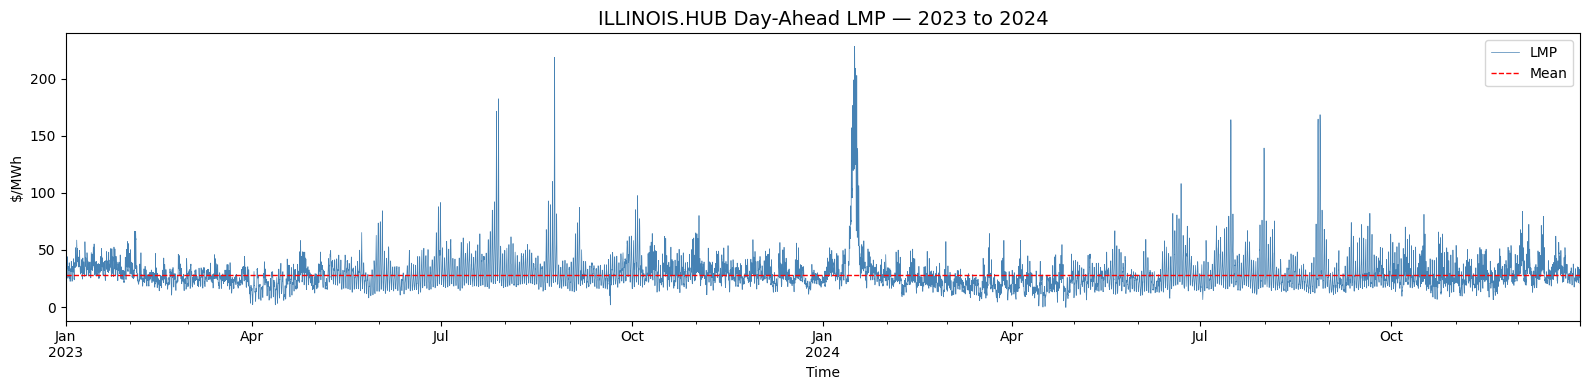

In [ ]:
# Full price history
fig, ax = plt.subplots(figsize=(16, 4))
da_lmp_full.set_index('Time')['LMP'].plot(ax=ax, linewidth=0.5, color='steelblue')
ax.set_title('ILLINOIS.HUB Day-Ahead LMP — 2023 to 2024', fontsize=14)
ax.set_ylabel('$/MWh')
ax.axhline(y=da_lmp_full['LMP'].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig('results/lmp_full_history.png', dpi=150)
plt.show()

This chart tells:
- **Most of the time** prices cluster between $20 -$50/MWh - that flat band is "normal". 
- **Summer spikes** (Jul-Sep 2023, July-Sep 2024) - heat waves driving AC load. 
- **The gaint January 2024 spike** - that's the polar vortex event we saw earlier ($228/MWh).
- **Prices are not random** - they follow a clear seasonal rhythm. 
What this tells the model:
We need features that capture season (month, summer flag, winter flag) and recent price history (was yersterday expensive?)

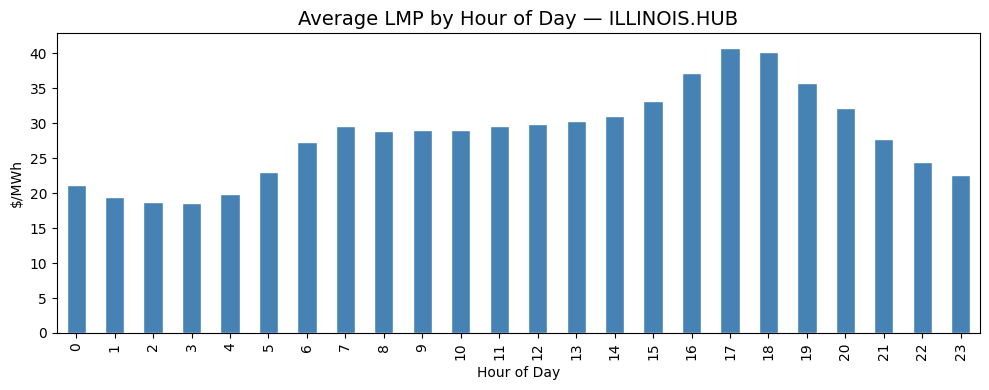

In [19]:
# Average price by hour of day (the daily curve)
df = da_lmp_full.copy()
df['hour'] = df['Time'].dt.hour

hourly_avg = df.groupby('hour')['LMP'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average LMP by Hour of Day — ILLINOIS.HUB', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('$/MWh')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig('results/lmp_by_hour.png', dpi=150)
plt.show()

This is one of the most important charts in the project. You can see:

Hours 1–4 = cheapest (~$19/MWh) — middle of the night, low demand
Hour 7 = morning ramp ($27) — people wake up, factories start
Hours 17–18 = most expensive (~$40/MWh) — evening peak, people get home, cook dinner, lights on, AC still running, but solar generation is dropping
Hour 23 = falling back (~$22) — people go to bed

This "dual hump" shape (morning + evening peak) is called the duck curve and it's the fundamental daily rhythm of electricity prices.
What this tells your model: Hour of day is your single most important feature. And it's not linear — hour 17 is not "just a bit more than hour 16." This is why we use sine/cosine encoding.

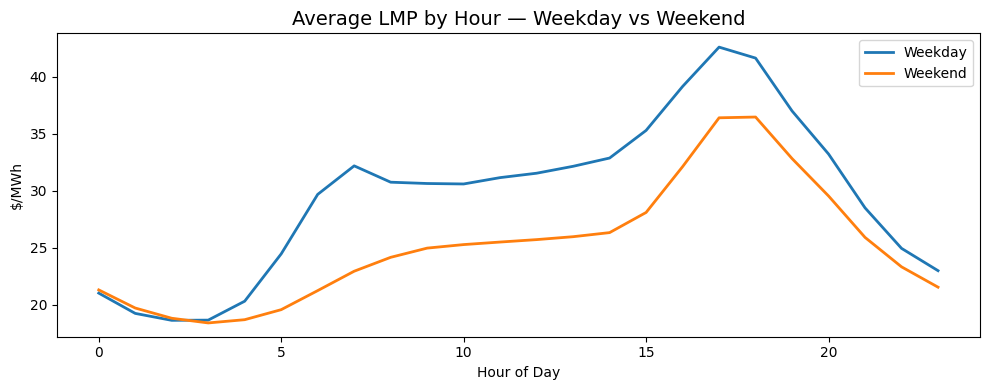

In [21]:
# Weekday v.s. Weedend
df['day_of_week'] = df['Time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6])

fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(['hour', 'is_weekend'])['LMP'].mean().unstack().plot(
    ax=ax, linewidth=2
)
ax.set_title('Average LMP by Hour — Weekday vs Weekend', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('$/MWh')
ax.legend(['Weekday', 'Weekend'])
plt.tight_layout()
plt.savefig('results/lmp_weekday_vs_weekend.png', dpi=150)
plt.show()

Three clear patterns:

Weekdays are consistently more expensive — industrial and commercial load is running
The gap is biggest at hours 6–20 — business hours
Overnight they converge — at 3am, nobody is working anyway
Evening peak is ~$42 on weekdays vs ~$36 on weekends — a $6/MWh difference just from the day of week

What this tells your model: is_weekend is a strong binary feature. A model that doesn't know what day of week it is will systematically over-predict on weekends and under-predict on weekdays.

## EDA Insights → Feature Mapping

| Observation | Feature It Drives |
|-------------|------------------|
| Strong hourly pattern | `hour_sin`, `hour_cos` |
| Weekday/weekend gap | `is_weekend`, `day_of_week` |
| Summer/winter spikes | `month`, `is_summer`, `is_winter` |
| Prices cluster then spike | `lmp_lag_24h`, `lmp_roll_std` |
| January polar vortex | `temperature`, `extreme_cold_flag` |

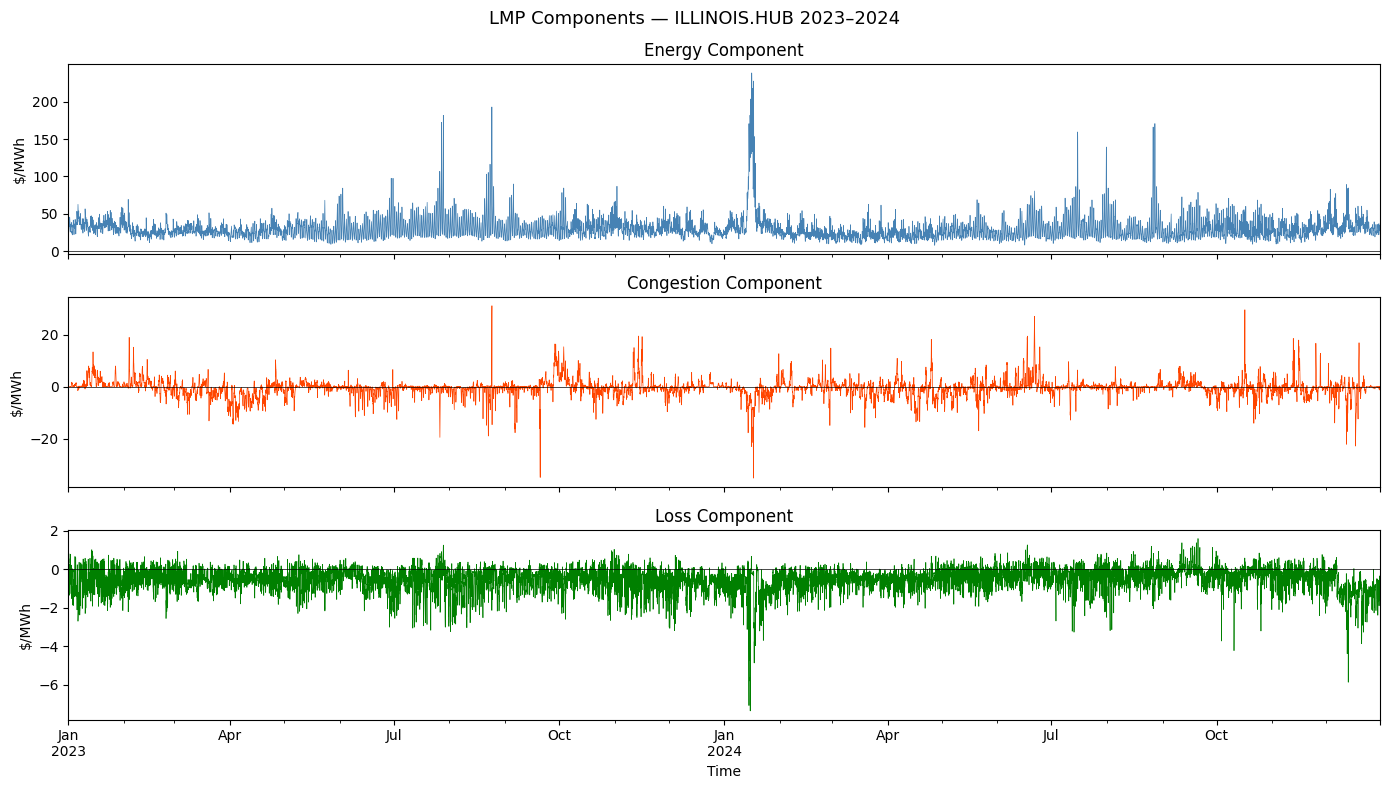

In [22]:
#  it shows the LMP components (Energy vs Congestion vs Loss) which tells you which part is hardest to forecast
df_comp = da_lmp_full.copy()
df_comp['hour'] = df_comp['Time'].dt.hour

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

components = ['Energy', 'Congestion', 'Loss']
colors = ['steelblue', 'orangered', 'green']

for ax, col, color in zip(axes, components, colors):
    df_comp.set_index('Time')[col].plot(ax=ax, linewidth=0.5, color=color)
    ax.set_ylabel('$/MWh')
    ax.set_title(f'{col} Component')
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('LMP Components — ILLINOIS.HUB 2023–2024', fontsize=13)
plt.tight_layout()
plt.savefig('results/lmp_components.png', dpi=150)
plt.show()

Reading the 3 components:
- Energy (Blue) - The predictable one
    - Stays mostly between $20–$50/MWh with clear spikes
    - Spikes are sharp but infrequent — they correspond to system-wide stress events (polar vortex, heat waves)
    - This component follows load and fuel prices closely
    - Most predictable of the three — your model will do best here
- Congestion (Orange) — The Noisy One
    - Oscillates around zero — can be positive OR negative
    - Has sudden large swings (notice the -$35 and +$25 spikes)
    - No clear seasonal trend — it depends on which transmission lines are congested that specific hour
    - Hardest to forecast — this is where your model will struggle most and where lagged congestion features matter
- Loss (Green) — Nearly Irrelevant
    - Tiny range: roughly -$4 to +$1/MWh
    - Essentially noise compared to Energy and Congestion
    - For a portfolio project you can largely ignore this component

**Total Error = Energy Error (manageable) + Congestion Error (hardest part) + Loss Error(tiny)**